In [18]:
import warnings
import pandas as pd
import numpy as np

# Suppress ALL warnings
warnings.filterwarnings('ignore')
pd.options.mode.chained_assignment = None  # Suppress pandas copy warnings

# Create the cache directory
cache_path = '/cache'
os.makedirs(cache_path, exist_ok=True)

# Now enable cache
fastf1.Cache.enable_cache(cache_path)

In [19]:
import fastf1
import pandas as pd

session = fastf1.get_session(2023, 'Monza', 'R')
session.load()

core           INFO 	Loading data for Italian Grand Prix - Race [v3.8.1]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core        WARNING 	Driver 1 completed the race distance 06:25.888000 before the recorded end of the session.
core        WARNING 	Driver 11 completed the race distance 06:19.824000 before the recorded end of the session.
core        WAR

In [28]:
import warnings
import logging
import pandas as pd
import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, roc_auc_score, confusion_matrix,
                           classification_report, average_precision_score)

# Suppress noise
warnings.filterwarnings('ignore')
logging.getLogger('fastf1').setLevel(logging.ERROR)

import fastf1
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def evaluate_pit_stop_model(model, X_test, y_test, y_pred, y_proba):
    """Comprehensive evaluation for imbalanced pit stop prediction"""
    
    results = {}
    
    # Basic metrics
    results['accuracy'] = accuracy_score(y_test, y_pred)
    results['precision'] = precision_score(y_test, y_pred, zero_division=0)
    results['recall'] = recall_score(y_test, y_pred, zero_division=0)
    results['f1'] = f1_score(y_test, y_pred, zero_division=0)
    results['roc_auc'] = roc_auc_score(y_test, y_proba)
    results['pr_auc'] = average_precision_score(y_test, y_proba)  # Better for imbalanced
    
    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    results['true_negatives'] = cm[0, 0]  # Correct no-pit predictions
    results['false_positives'] = cm[0, 1]  # Predicted pit but no pit
    results['false_negatives'] = cm[1, 0]  # Missed pit stops
    results['true_positives'] = cm[1, 1]  # Correct pit predictions
    
    return results

# Load your data
print("🏎️ Loading race data...")
f1_cache_path = './fastf1_cache'
os.makedirs(f1_cache_path, exist_ok=True)
fastf1.Cache.enable_cache('./fastf1_cache')
session = fastf1.get_session(2023, 'Monza', 'R')
session.load()

# Prepare data with weather (as before)
data = []
for driver in session.laps['Driver'].unique():
    driver_laps = session.laps[session.laps['Driver'] == driver].sort_values('LapNumber')
    
    # Find weather for each lap (simplified)
    for i in range(len(driver_laps) - 1):
        current = driver_laps.iloc[i]
        next_lap = driver_laps.iloc[i + 1]
        
        will_pit = pd.notna(next_lap['PitOutTime'])
        
        if pd.notna(current['TyreLife']):
            data.append({
                'tyre_age': float(current['TyreLife']),
                'lap_num': float(current['LapNumber']),
                'will_pit': will_pit
            })

df = pd.DataFrame(data)

# Train model
X = df[['tyre_age', 'lap_num']]
y = df['will_pit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Use class_weight to handle imbalance
model = LogisticRegression(class_weight='balanced', random_state=42)
model.fit(X_train_scaled, y_train)

# Predict
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Evaluate
results = evaluate_pit_stop_model(model, X_test_scaled, y_test, y_pred, y_proba)

print("\n" + "="*60)
print("📊 PIT STOP PREDICTION MODEL EVALUATION")
print("="*60)

print(f"\n📈 Dataset Balance:")
print(f"  Total laps: {len(df)}")
print(f"  Pit stops: {df['will_pit'].sum()} ({df['will_pit'].mean()*100:.1f}%)")
print(f"  No pits: {(~df['will_pit']).sum()} ({(1-df['will_pit'].mean())*100:.1f}%)")

print(f"\n🎯 Key Metrics (for imbalanced data):")
print(f"  Precision: {results['precision']:.3f} - Accuracy of pit predictions")
print(f"  Recall: {results['recall']:.3f} - % of pits caught")
print(f"  F1-Score: {results['f1']:.3f} - Balance between precision & recall")
print(f"  ROC-AUC: {results['roc_auc']:.3f} - Ranking quality (0.5=random, 1.0=perfect)")
print(f"  PR-AUC: {results['pr_auc']:.3f} - Better for rare events")

print(f"\n📊 Confusion Matrix:")
print(f"  True Negatives (correct no-pit): {results['true_negatives']}")
print(f"  False Positives (false alarms): {results['false_positives']}")
print(f"  False Negatives (missed pits): {results['false_negatives']}")
print(f"  True Positives (correct pits): {results['true_positives']}")

print(f"\n📋 Full Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Pit', 'Pit']))

🏎️ Loading race data...

📊 PIT STOP PREDICTION MODEL EVALUATION

📈 Dataset Balance:
  Total laps: 938
  Pit stops: 25 (2.7%)
  No pits: 913 (97.3%)

🎯 Key Metrics (for imbalanced data):
  Precision: 0.094 - Accuracy of pit predictions
  Recall: 0.600 - % of pits caught
  F1-Score: 0.162 - Balance between precision & recall
  ROC-AUC: 0.827 - Ranking quality (0.5=random, 1.0=perfect)
  PR-AUC: 0.289 - Better for rare events

📊 Confusion Matrix:
  True Negatives (correct no-pit): 154
  False Positives (false alarms): 29
  False Negatives (missed pits): 2
  True Positives (correct pits): 3

📋 Full Classification Report:
              precision    recall  f1-score   support

      No Pit       0.99      0.84      0.91       183
         Pit       0.09      0.60      0.16         5

    accuracy                           0.84       188
   macro avg       0.54      0.72      0.54       188
weighted avg       0.96      0.84      0.89       188



🌦️ Race Weather Summary:
  Air Temperature: 28.4°C - 30.3°C
  Track Temperature: 39.3°C - 44.4°C
  Humidity: 39.0% - 46.0%
  Rainfall detected: No
  Wind Speed: 0.0 - 2.4 km/h


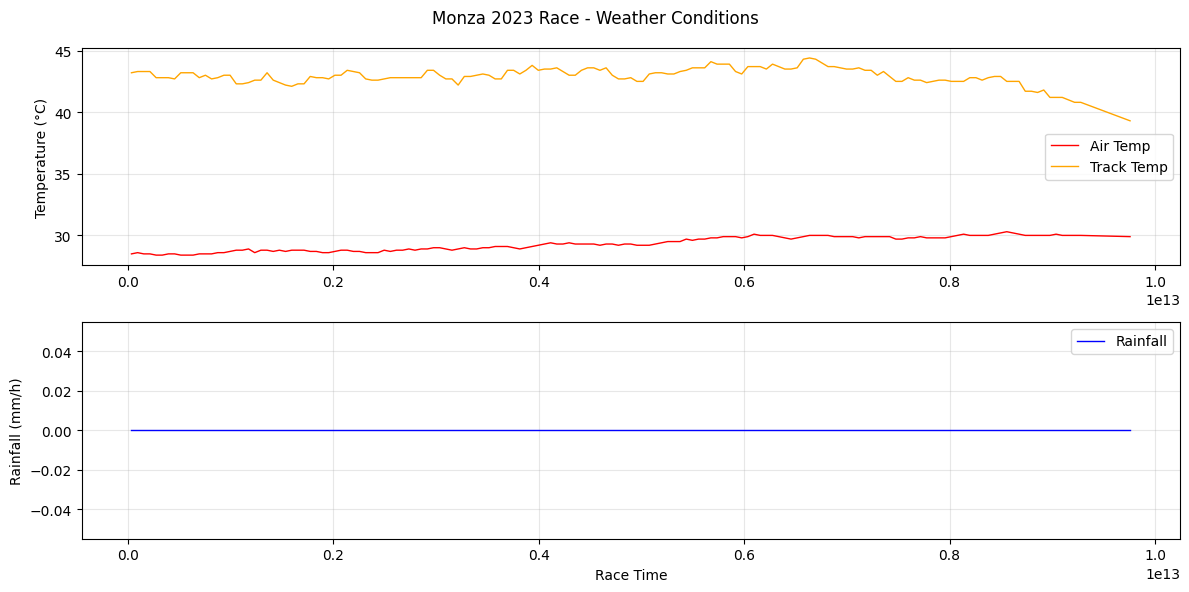

In [22]:
import matplotlib.pyplot as plt

# Get weather throughout race
weather = session.weather_data

print("🌦️ Race Weather Summary:")
print(f"  Air Temperature: {weather['AirTemp'].min():.1f}°C - {weather['AirTemp'].max():.1f}°C")
print(f"  Track Temperature: {weather['TrackTemp'].min():.1f}°C - {weather['TrackTemp'].max():.1f}°C")
print(f"  Humidity: {weather['Humidity'].min():.1f}% - {weather['Humidity'].max():.1f}%")
print(f"  Rainfall detected: {'Yes' if weather['Rainfall'].sum() > 0 else 'No'}")
print(f"  Wind Speed: {weather['WindSpeed'].min():.1f} - {weather['WindSpeed'].max():.1f} km/h")

# Plot weather trends
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

# Temperature
axes[0].plot(weather['Time'], weather['AirTemp'], 'r-', label='Air Temp', linewidth=1)
axes[0].plot(weather['Time'], weather['TrackTemp'], 'orange', label='Track Temp', linewidth=1)
axes[0].set_ylabel('Temperature (°C)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Rainfall
axes[1].plot(weather['Time'], weather['Rainfall'], 'b-', label='Rainfall', linewidth=1)
axes[1].set_ylabel('Rainfall (mm/h)')
axes[1].set_xlabel('Race Time')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Monza 2023 Race - Weather Conditions')
plt.tight_layout()
plt.show()

In [23]:
import numpy as np

# Match weather to pit stops
pit_stops_with_weather = []

for idx, lap in session.laps.iterrows():
    if pd.notna(lap['PitInTime']):  # Pit stop occurred
        # Find weather closest to pit time
        pit_time = lap['PitInTime']
        weather_at_pit = session.weather_data.iloc[
            (session.weather_data['Time'] - pit_time).abs().argsort()[:1]
        ].iloc[0]
        
        pit_stops_with_weather.append({
            'driver': lap['Driver'],
            'lap': lap['LapNumber'],
            'tyre_age': lap['TyreLife'],
            'air_temp': weather_at_pit['AirTemp'],
            'track_temp': weather_at_pit['TrackTemp'],
            'humidity': weather_at_pit['Humidity'],
            'rainfall': weather_at_pit['Rainfall']
        })

pit_df = pd.DataFrame(pit_stops_with_weather)

print("🌧️ Pit Stops and Weather Conditions:")
print(pit_df.head(10))

print(f"\n📊 Weather During Pit Stops:")
print(f"  Avg Air Temp: {pit_df['air_temp'].mean():.1f}°C")
print(f"  Avg Track Temp: {pit_df['track_temp'].mean():.1f}°C")
print(f"  Pits in rain: {(pit_df['rainfall'] > 0).sum()}")

🌧️ Pit Stops and Weather Conditions:
  driver   lap  tyre_age  air_temp  track_temp  humidity  rainfall
0    VER  20.0      20.0      30.0        44.3      39.0     False
1    GAS  10.0      10.0      29.9        43.9      41.0     False
2    GAS  31.0      24.0      29.9        42.6      41.0     False
3    PER  21.0      21.0      30.0        44.0      39.0     False
4    ALO  21.0      21.0      30.0        44.0      39.0     False
5    LEC  20.0      20.0      30.0        44.3      39.0     False
6    STR  20.0      20.0      30.0        44.3      39.0     False
7    SAR  14.0      17.0      30.0        43.7      42.0     False
8    MAG  12.0      16.0      29.9        43.7      41.0     False
9    MAG  33.0      21.0      29.8        42.6      41.0     False

📊 Weather During Pit Stops:
  Avg Air Temp: 29.9°C
  Avg Track Temp: 43.5°C
  Pits in rain: 0


In [24]:
# Create features that combine weather with pit decisions
def add_weather_features(laps_df, weather_df):
    """Add weather conditions to each lap"""
    df = laps_df.copy()
    
    # Match weather to each lap
    df['air_temp'] = None
    df['track_temp'] = None
    df['humidity'] = None
    df['rainfall'] = None
    
    for idx, lap in df.iterrows():
        if pd.notna(lap['Time']):
            # Find closest weather reading
            closest = weather_df.iloc[
                (weather_df['Time'] - lap['Time']).abs().argsort()[:1]
            ].iloc[0]
            
            df.at[idx, 'air_temp'] = closest['AirTemp']
            df.at[idx, 'track_temp'] = closest['TrackTemp']
            df.at[idx, 'humidity'] = closest['Humidity']
            df.at[idx, 'rainfall'] = closest['Rainfall']
    
    return df

# Add weather to laps
laps_with_weather = add_weather_features(session.laps, session.weather_data)

print("🏎️ Lap Data with Weather (sample):")
print(laps_with_weather[['Driver', 'LapNumber', 'TyreLife', 'air_temp', 'track_temp', 'rainfall']].head(10))

🏎️ Lap Data with Weather (sample):
  Driver  LapNumber  TyreLife air_temp track_temp rainfall
0    VER        1.0       1.0     29.2       42.5    False
1    VER        2.0       2.0     29.3       43.2    False
2    VER        3.0       3.0     29.4       43.2    False
3    VER        4.0       4.0     29.5       43.1    False
4    VER        5.0       5.0     29.5       43.3    False
5    VER        6.0       6.0     29.7       43.4    False
6    VER        7.0       7.0     29.7       43.6    False
7    VER        8.0       8.0     29.7       43.6    False
8    VER        9.0       9.0     29.8       43.9    False
9    VER       10.0      10.0     29.9       43.9    False


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Prepare data with weather
X_weather = []
y_weather = []

for driver in session.laps['Driver'].unique():
    driver_laps = laps_with_weather[laps_with_weather['Driver'] == driver].sort_values('LapNumber')
    
    for i in range(len(driver_laps) - 1):
        current = driver_laps.iloc[i]
        next_lap = driver_laps.iloc[i + 1]
        
        will_pit = pd.notna(next_lap['PitOutTime'])
        
        # Features including weather
        if pd.notna(current['TyreLife']):
            features = [
                current['TyreLife'],           # Tyre age
                current['LapNumber'],          # Race progress
                current['track_temp'] if pd.notna(current['track_temp']) else 30,
                current['rainfall'] if pd.notna(current['rainfall']) else 0,
                current['humidity'] if pd.notna(current['humidity']) else 50
            ]
            
            X_weather.append(features)
            y_weather.append(will_pit)

# Train model with weather
X_weather = np.array(X_weather)
y_weather = np.array(y_weather)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_weather)

model_weather = LogisticRegression()
model_weather.fit(X_scaled, y_weather)

print("\n🌡️ Model with Weather Features:")
print(f"  Accuracy: {model_weather.score(X_scaled, y_weather):.3f}")

feature_names = ['Tyre Age', 'Lap Number', 'Track Temp', 'Rainfall', 'Humidity']
print(f"\n  Feature Importance:")
for name, coef in zip(feature_names, model_weather.coef_[0]):
    print(f"    {name}: {coef:.3f}")


🌡️ Model with Weather Features:
  Accuracy: 0.973

  Feature Importance:
    Tyre Age: 1.979
    Lap Number: -0.576
    Track Temp: 1.308
    Rainfall: 0.000
    Humidity: 0.242
